In [17]:
# Load transitivity sweep CSV and build a NumPy array
# trans: shape = (num_targetC, repeats)

import csv
import os
from collections import defaultdict, OrderedDict
import numpy as np


def load_trans_matrix(csv_path: str):
    """Load transitivity sweep CSV and return targets and transitivity matrix."""
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")

    # Preserve first-seen order of targetC values
    order = OrderedDict()
    groups = defaultdict(list)  # targetC -> list of (repeat_idx?, trans)

    with open(csv_path, newline="") as f:
        reader = csv.DictReader(f)
        required = {"target_transitivity", "transitivity"}
        missing = required - set(reader.fieldnames or [])
        if missing:
            raise ValueError(f"CSV missing columns: {sorted(missing)}")

        has_repeat = "repeat" in reader.fieldnames
        for row in reader:
            try:
                target_c = float(row["target_transitivity"])  # input target
                trans = float(row["transitivity"])                   # measured value
            except Exception as e:
                raise ValueError(f"Failed to parse row: {row}") from e

            if target_c not in order:
                order[target_c] = len(order)

            if has_repeat:
                try:
                    rep = int(row["repeat"])  # 0..repeats-1 expected
                except Exception:
                    rep = None
                groups[target_c].append((rep, trans))
            else:
                groups[target_c].append((None, trans))

    # Determine repeats and build matrix
    targets = list(order.keys())
    counts = [len(groups[t]) for t in targets]
    if not counts:
        raise ValueError("No data rows in CSV.")
    repeats = max(counts)
    if any(c != repeats for c in counts):
        raise ValueError(f"Unequal repeat counts per targetC: {counts}")

    trans_mat = np.full((len(targets), repeats), np.nan, dtype=float)

    for ti, tval in enumerate(targets):
        items = groups[tval]
        # If repeat indices exist and cover 0..repeats-1, place by index; else fill in order
        by_idx = [x for x in items if x[0] is not None]
        if len(by_idx) == repeats and sorted(r for r, _ in by_idx) == list(range(repeats)):
            for r, v in by_idx:
                trans_mat[ti, r] = v
        else:
            for r, (_, v) in enumerate(items):
                trans_mat[ti, r] = v

    return np.array(targets, dtype=float), trans_mat



In [20]:
# Load the transitivity sweep data
csv_path = os.path.join(
    "output", 
    "edge-triangle",
    "z=6",
    "N=10000",
    "transitivity-sweep.csv"
)

targets, trans = load_trans_matrix(csv_path)

print(f"Loaded: {csv_path}")
print(f"targets shape: {targets.shape}; repeats: {trans.shape[1]}")
print(f"trans shape: {trans.shape}")
print(f"targetC min..max: {targets.min():.4f} .. {targets.max():.4f}")
print(f"trans sample (first row): {trans[0] if len(trans) else '[]'}")


Loaded: output/edge-triangle/z=6/N=10000/transitivity-sweep.csv
targets shape: (21,); repeats: 100
trans shape: (21, 100)
targetC min..max: 0.0000 .. 0.4000
trans sample (first row): [0.0002  0.00046 0.0004  0.00032 0.00054 0.00046 0.00036 0.00026 0.00036
 0.00032 0.00048 0.00046 0.00042 0.0005  0.00026 0.00034 0.00042 0.00026
 0.00032 0.00046 0.0004  0.00052 0.0006  0.00024 0.00032 0.0004  0.00032
 0.00036 0.00052 0.0004  0.00042 0.00048 0.00036 0.00044 0.00046 0.00026
 0.00042 0.0004  0.00038 0.00044 0.00042 0.00048 0.00038 0.00036 0.00032
 0.00038 0.00034 0.00044 0.00032 0.00034 0.00054 0.00052 0.00048 0.0004
 0.00046 0.00034 0.00048 0.00052 0.00046 0.00036 0.00056 0.0005  0.00036
 0.00028 0.00044 0.00036 0.00026 0.00038 0.00034 0.00042 0.0004  0.0005
 0.00046 0.00052 0.0003  0.00052 0.0005  0.00046 0.0005  0.00038 0.0007
 0.00036 0.00036 0.00038 0.0005  0.0005  0.00036 0.00036 0.00046 0.00038
 0.00054 0.00038 0.00026 0.00042 0.00038 0.00036 0.00056 0.00058 0.00034
 0.00054]


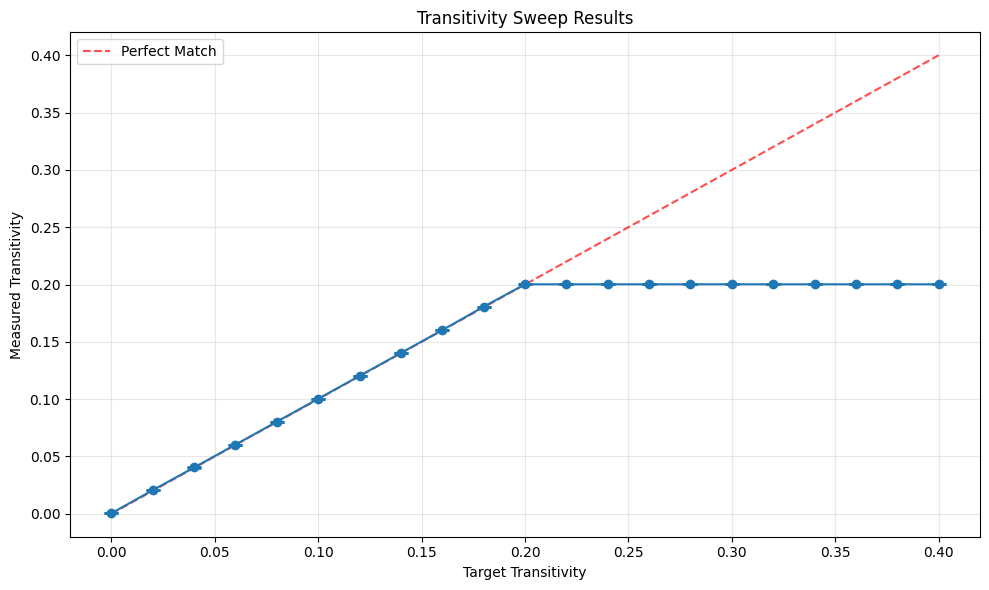


Statistics:
Mean absolute error: 0.0525
Max absolute error: 0.1998
Correlation coefficient: 0.8937


In [21]:
# Visualize the transitivity data
import matplotlib.pyplot as plt

# Calculate mean and std for each target transitivity
trans_mean = np.nanmean(trans, axis=1)
trans_std = np.nanstd(trans, axis=1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.errorbar(targets, trans_mean, yerr=trans_std, fmt='o-', capsize=5, capthick=2)
plt.xlabel('Target Transitivity')
plt.ylabel('Measured Transitivity')
plt.title('Transitivity Sweep Results')
plt.grid(True, alpha=0.3)

# Add diagonal line for perfect match
plt.plot([targets.min(), targets.max()], [targets.min(), targets.max()], 'r--', alpha=0.7, label='Perfect Match')
plt.legend()

plt.tight_layout()
plt.show()

# Print some statistics
print(f"\nStatistics:")
print(f"Mean absolute error: {np.mean(np.abs(trans_mean - targets)):.4f}")
print(f"Max absolute error: {np.max(np.abs(trans_mean - targets)):.4f}")
print(f"Correlation coefficient: {np.corrcoef(targets, trans_mean)[0,1]:.4f}")
